# IPL Data Analytics Project (2008–2026)

**Author:** Aditya
**Dataset:** `IPL_Matches_Data_2008_2026.csv` — ball-by-ball-level match metadata for every Indian Premier League match from the 2008 season through 2026 (1,243 matches).

This notebook performs end-to-end exploratory data analysis (EDA) on IPL match data: cleaning, descriptive statistics, and visual analysis of team performance, toss trends, scoring patterns, venues, and player awards.

## Table of Contents
1. Setup & Data Loading
2. Data Cleaning & Preprocessing
3. Dataset Overview
4. Season-wise Match Trends
5. Team Performance Analysis
6. Toss Analysis
7. Scoring Analysis
8. Venue Analysis
9. Player of the Match Analysis
10. Win Margin Analysis
11. Key Insights & Conclusion


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', None)


## 1. Setup & Data Loading

Load the raw CSV file. Update `DATA_PATH` if running this notebook from a different location.

In [2]:
DATA_PATH = "IPL_Matches_Data_2008_2026.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (1243, 31)


,event_name,season,match_number,date,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,team2_runs,team2_wickets,winner,result_type,win_by_runs,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,match_type,overs_limit,balls_per_over,gender,team_type,team1_players,team2_players
0,Indian Premier League,2007/08,1.0,18-04-2008,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,82,10,222,3,Kolkata Knight Riders,complete,140,0,BB McCullum,J Srinath,Asad Rauf,RE Koertzen,AM Saheba,VN Kulkarni,T20,20,6,male,club,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey..."
1,Indian Premier League,2007/08,2.0,19-04-2008,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,207,4,240,5,Chennai Super Kings,complete,33,0,MEK Hussey,S Venkataraghavan,MR Benson,SL Shastri,RB Tiffin,MSS Ranawat,T20,20,6,male,club,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ..."
2,Indian Premier League,2007/08,3.0,19-04-2008,Delhi,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,132,1,129,8,Delhi Daredevils,complete,0,9,MF Maharoof,GR Viswanath,Aleem Dar,GA Pratapkumar,IL Howell,Unknown,T20,20,6,male,club,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm..."
3,Indian Premier League,2007/08,4.0,20-04-2008,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,112,5,110,10,Kolkata Knight Riders,complete,0,5,DJ Hussey,FM Engineer,BF Bowden,K Hariharan,Asad Rauf,F Gomes,T20,20,6,male,club,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S..."
4,Indian Premier League,2007/08,5.0,20-04-2008,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,165,7,166,5,Royal Challengers Bangalore,complete,0,5,MV Boucher,J Srinath,SJ Davis,DJ Harper,AV Jayaprakash,SN Bandekar,T20,20,6,male,club,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli..."


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_name       1243 non-null   str    
 1   season           1243 non-null   str    
 2   match_number     1169 non-null   float64
 3   date             1243 non-null   str    
 4   city             1243 non-null   str    
 5   venue            1243 non-null   str    
 6   team1            1243 non-null   str    
 7   team2            1243 non-null   str    
 8   toss_winner      1243 non-null   str    
 9   toss_decision    1243 non-null   str    
 10  team1_runs       1243 non-null   int64  
 11  team1_wickets    1243 non-null   int64  
 12  team2_runs       1243 non-null   int64  
 13  team2_wickets    1243 non-null   int64  
 14  winner           1218 non-null   str    
 15  result_type      1243 non-null   str    
 16  win_by_runs      1243 non-null   int64  
 17  win_by_wickets   1243 non

## 2. Data Cleaning & Preprocessing

Two things need handling before analysis:

1. **Franchise renames** — several IPL franchises changed names over the years while remaining the same entity (e.g. Delhi Daredevils → Delhi Capitals). We map these to their current names so team-level stats aren't split across old/new identities.
2. **Date parsing** — the `date` column is stored as `dd-mm-yyyy` text and needs conversion to a proper datetime.
3. **Missing values** — `winner` is null for tied/no-result matches, and `match_number` has some gaps; both are expected and left as-is (not imputed) since they reflect real match outcomes.

In [4]:
rename_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
}
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    df[col] = df[col].replace(rename_map)

df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')
df['season_clean'] = df['season'].astype(str).str[:4]

print("Missing values per column:")
df.isna().sum()[df.isna().sum() > 0]


Missing values per column:


match_number       74
winner             25
player_of_match     9
dtype: int64

## 3. Dataset Overview

High-level shape of the competition across its history.

In [5]:
print(f"Total matches: {len(df)}")
print(f"Seasons covered: {df['season'].nunique()} ({df['season'].min()} to {df['season'].max()})")
print(f"Unique teams: {len(set(df['team1']).union(set(df['team2'])))}")
print(f"Unique venues: {df['venue'].nunique()}")
print(f"Unique cities: {df['city'].nunique()}")
print()
print(df['result_type'].value_counts())


Total matches: 1243
Seasons covered: 19 (2007/08 to 2026)
Unique teams: 15
Unique venues: 60
Unique cities: 38

result_type
complete     1218
tie            16
no result       9
Name: count, dtype: int64


## 4. Season-wise Match Trends

How many matches were played each season (varies with number of franchises and format changes such as COVID-affected seasons).

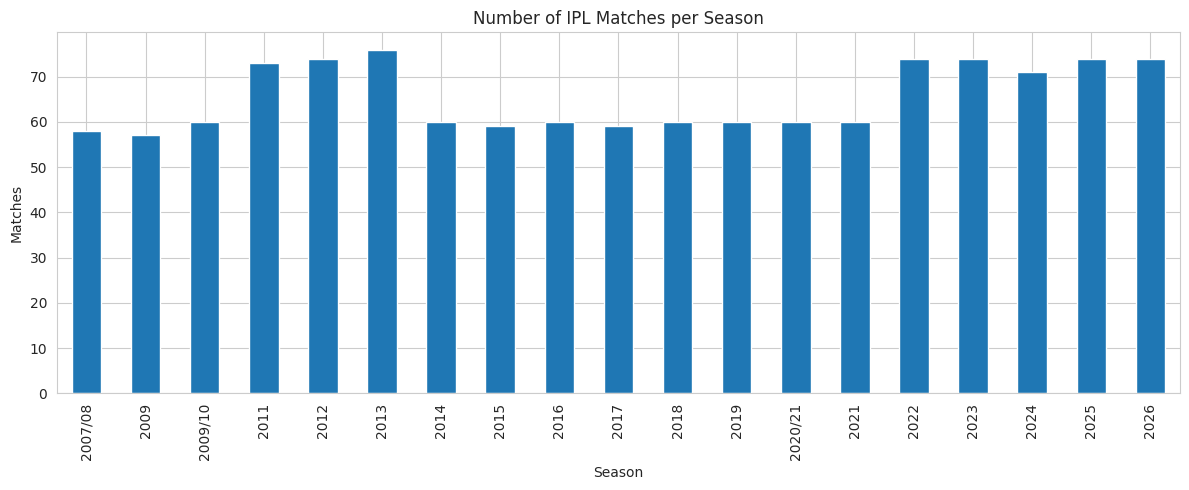

In [6]:
matches_per_season = df.groupby('season', sort=False).size()

plt.figure(figsize=(12,5))
matches_per_season.plot(kind='bar', color='#1f77b4')
plt.title('Number of IPL Matches per Season')
plt.ylabel('Matches')
plt.xlabel('Season')
plt.tight_layout()
plt.show()


## 5. Team Performance Analysis

### 5.1 Total wins by team

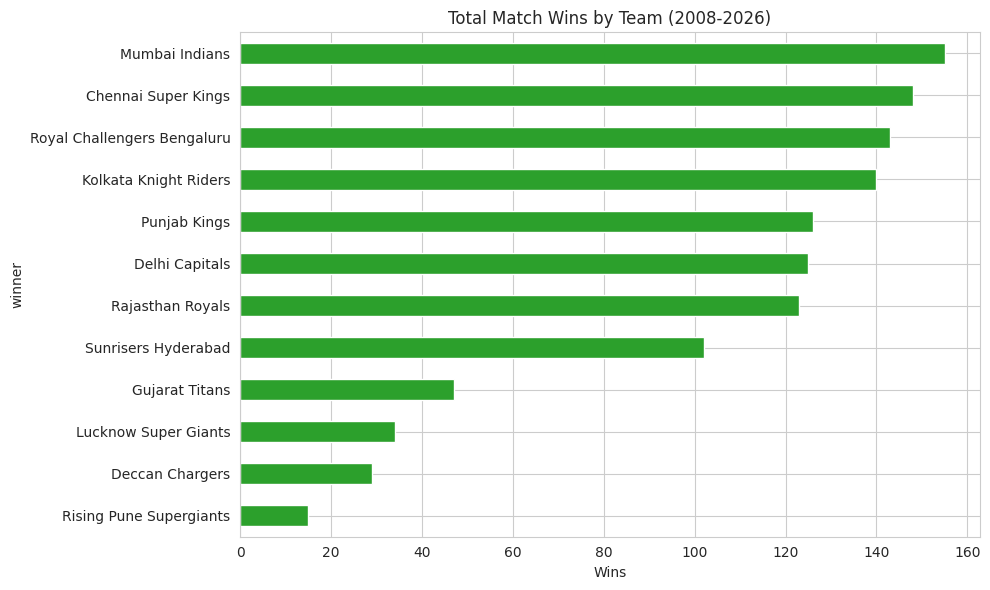

winner
Mumbai Indians                 155
Chennai Super Kings            148
Royal Challengers Bengaluru    143
Kolkata Knight Riders          140
Punjab Kings                   126
Delhi Capitals                 125
Rajasthan Royals               123
Sunrisers Hyderabad            102
Gujarat Titans                  47
Lucknow Super Giants            34
Deccan Chargers                 29
Rising Pune Supergiants         15
Name: count, dtype: int64

In [7]:
team_wins = df['winner'].value_counts().head(12)

plt.figure(figsize=(10,6))
team_wins.sort_values().plot(kind='barh', color='#2ca02c')
plt.title('Total Match Wins by Team (2008-2026)')
plt.xlabel('Wins')
plt.tight_layout()
plt.show()

team_wins


### 5.2 Win percentage (teams with 30+ matches played)

Raw win counts favor teams that have played the most seasons. Win % normalizes for that.

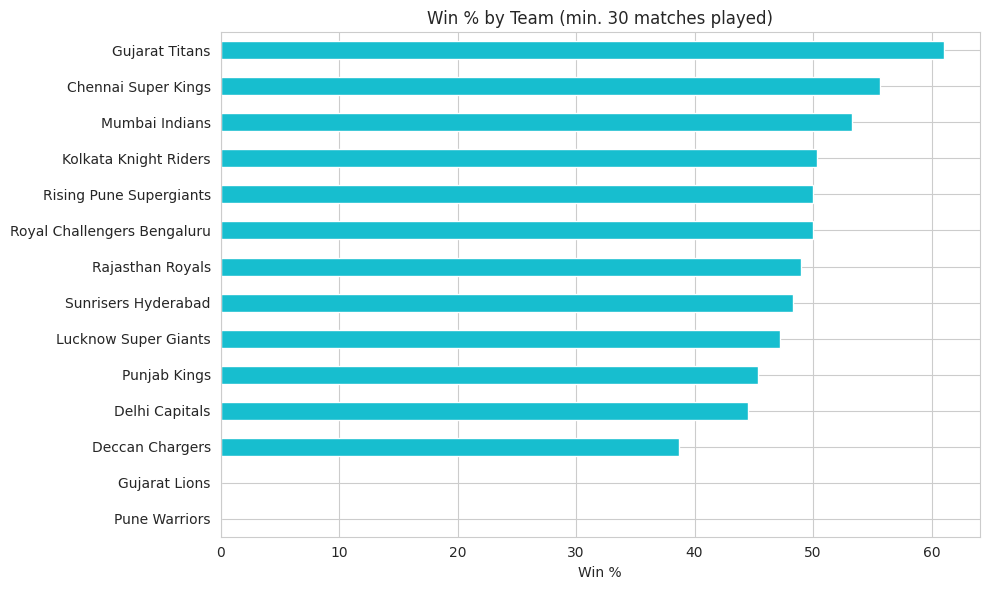

Gujarat Titans                 61.0
Chennai Super Kings            55.6
Mumbai Indians                 53.3
Kolkata Knight Riders          50.4
Rising Pune Supergiants        50.0
Royal Challengers Bengaluru    50.0
Rajasthan Royals               49.0
Sunrisers Hyderabad            48.3
Lucknow Super Giants           47.2
Punjab Kings                   45.3
Delhi Capitals                 44.5
Deccan Chargers                38.7
Pune Warriors                   0.0
Gujarat Lions                   0.0
Name: count, dtype: float64

In [8]:
team_matches = pd.concat([df['team1'], df['team2']]).value_counts()
team_win_pct = (team_wins.reindex(team_matches.index).fillna(0) / team_matches * 100).dropna()
team_win_pct = team_win_pct[team_matches >= 30].sort_values(ascending=False)

plt.figure(figsize=(10,6))
team_win_pct.sort_values().plot(kind='barh', color='#17becf')
plt.title('Win % by Team (min. 30 matches played)')
plt.xlabel('Win %')
plt.tight_layout()
plt.show()

team_win_pct.round(1)


## 6. Toss Analysis

### 6.1 Bat vs Field decision split

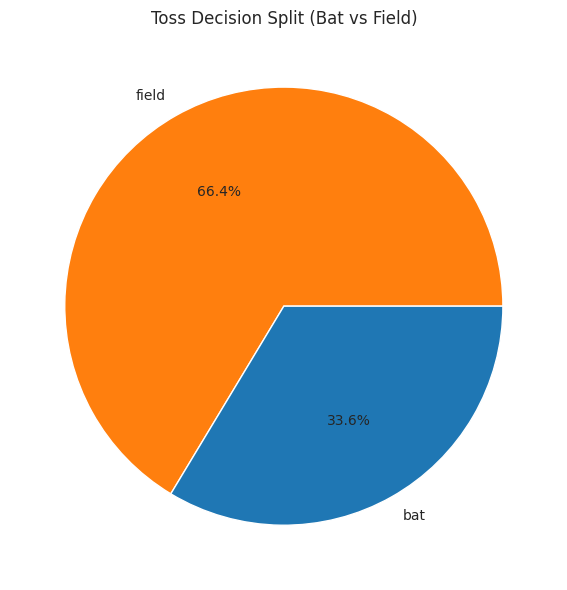

toss_decision
field    66.4
bat      33.6
Name: proportion, dtype: float64

In [9]:
toss_pct = df['toss_decision'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))
plt.pie(toss_pct, labels=toss_pct.index, autopct='%1.1f%%', colors=['#ff7f0e','#1f77b4'])
plt.title('Toss Decision Split (Bat vs Field)')
plt.tight_layout()
plt.show()

toss_pct.round(1)


### 6.2 Does winning the toss help win the match?

Overall: toss winner also wins the match in 51.6% of completed matches


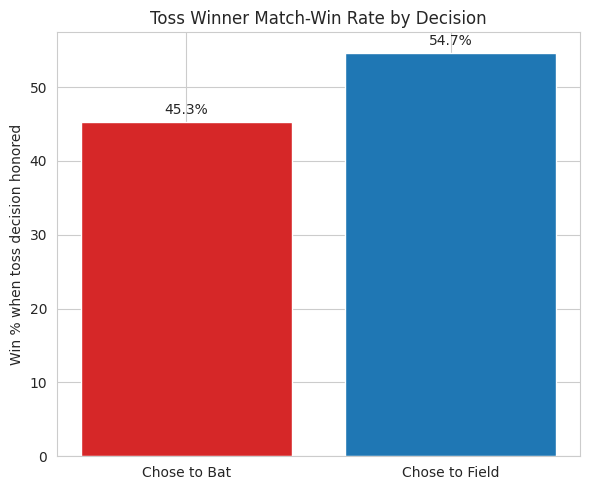

In [10]:
df_complete = df[df['result_type'] == 'complete'].copy()
df_complete['toss_and_match_winner'] = df_complete['toss_winner'] == df_complete['winner']

toss_win_rate = df_complete['toss_and_match_winner'].mean() * 100
print(f"Overall: toss winner also wins the match in {toss_win_rate:.1f}% of completed matches")

bat_win = df_complete[df_complete['toss_decision']=='bat']['toss_and_match_winner'].mean()*100
field_win = df_complete[df_complete['toss_decision']=='field']['toss_and_match_winner'].mean()*100

plt.figure(figsize=(6,5))
bars = plt.bar(['Chose to Bat','Chose to Field'], [bat_win, field_win], color=['#d62728','#1f77b4'])
plt.ylabel('Win % when toss decision honored')
plt.title('Toss Winner Match-Win Rate by Decision')
for i, v in enumerate([bat_win, field_win]):
    plt.text(i, v+1, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()


## 7. Scoring Analysis

### 7.1 Distribution of innings totals across all matches

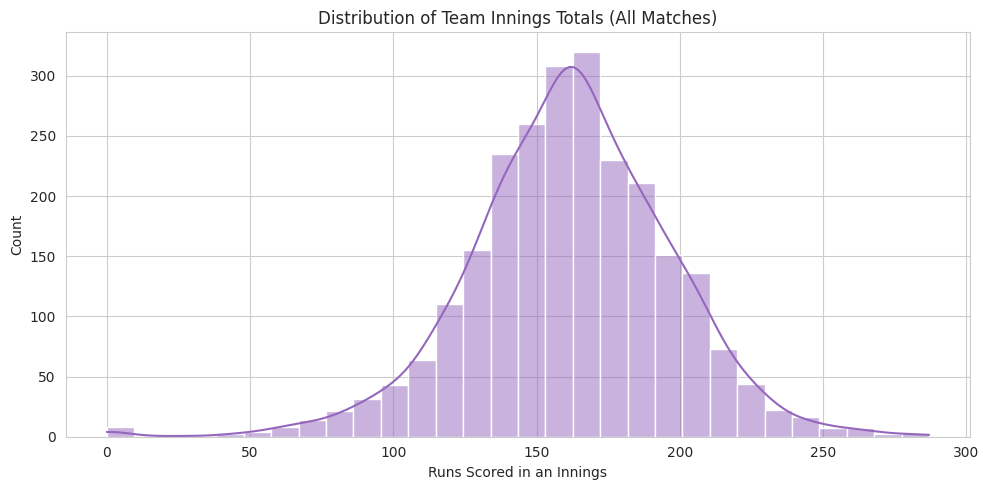

Highest team total: 287
Average innings total: 161.6
Lowest team total: 0


In [11]:
all_scores = pd.concat([df['team1_runs'], df['team2_runs']])

plt.figure(figsize=(10,5))
sns.histplot(all_scores, bins=30, kde=True, color='#9467bd')
plt.title('Distribution of Team Innings Totals (All Matches)')
plt.xlabel('Runs Scored in an Innings')
plt.tight_layout()
plt.show()

print(f"Highest team total: {all_scores.max()}")
print(f"Average innings total: {all_scores.mean():.1f}")
print(f"Lowest team total: {all_scores.min()}")


## 8. Venue Analysis

Which grounds have hosted the most IPL matches?

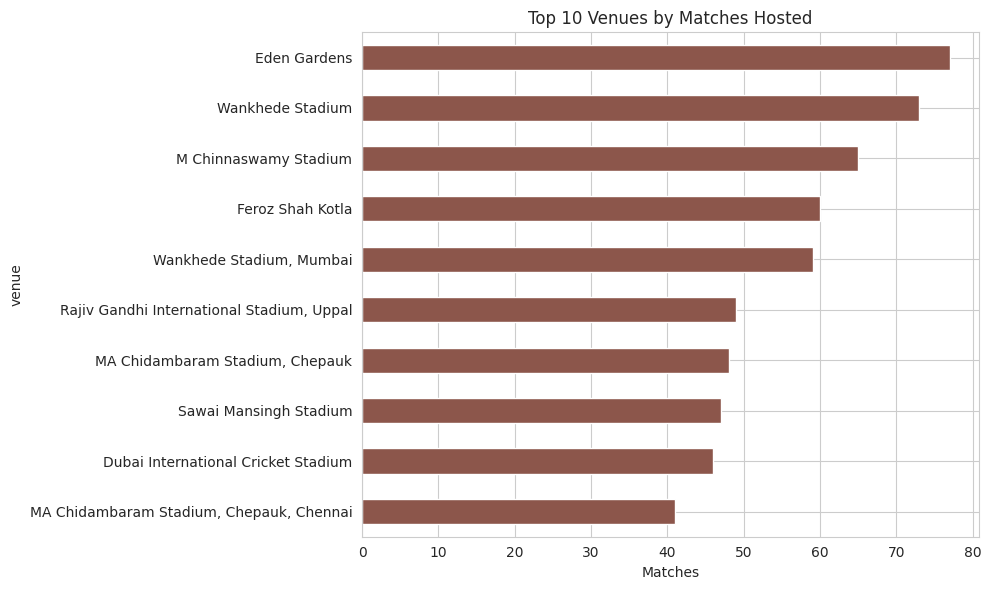

venue
Eden Gardens                                 77
Wankhede Stadium                             73
M Chinnaswamy Stadium                        65
Feroz Shah Kotla                             60
Wankhede Stadium, Mumbai                     59
Rajiv Gandhi International Stadium, Uppal    49
MA Chidambaram Stadium, Chepauk              48
Sawai Mansingh Stadium                       47
Dubai International Cricket Stadium          46
MA Chidambaram Stadium, Chepauk, Chennai     41
Name: count, dtype: int64

In [12]:
venue_counts = df['venue'].value_counts().head(10)

plt.figure(figsize=(10,6))
venue_counts.sort_values().plot(kind='barh', color='#8c564b')
plt.title('Top 10 Venues by Matches Hosted')
plt.xlabel('Matches')
plt.tight_layout()
plt.show()

venue_counts


## 9. Player of the Match Analysis

Most consistent individual performers across IPL history.

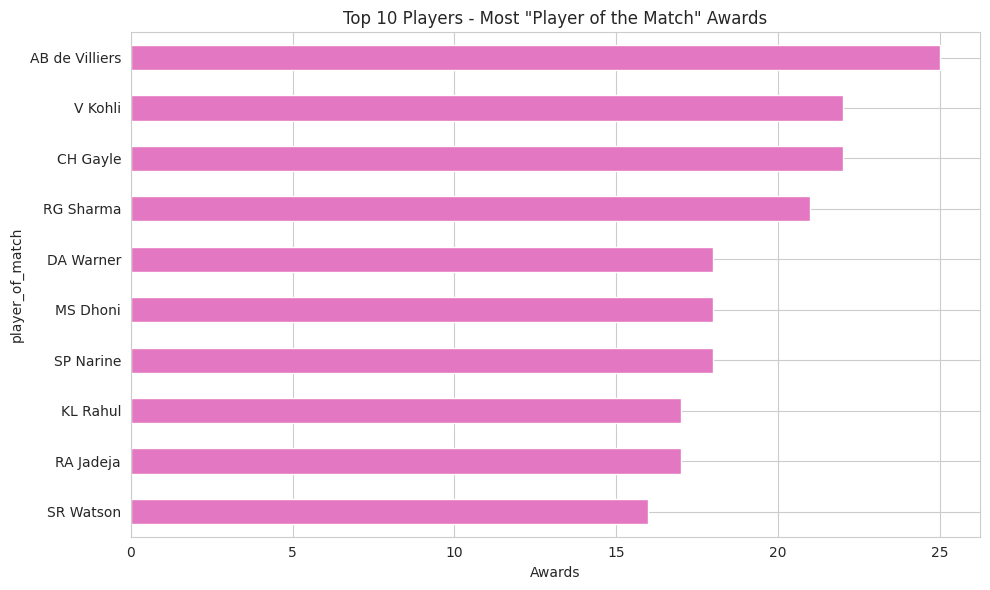

player_of_match
AB de Villiers    25
CH Gayle          22
V Kohli           22
RG Sharma         21
MS Dhoni          18
DA Warner         18
SP Narine         18
RA Jadeja         17
KL Rahul          17
SR Watson         16
Name: count, dtype: int64

In [13]:
pom_counts = df['player_of_match'].value_counts().head(10)

plt.figure(figsize=(10,6))
pom_counts.sort_values().plot(kind='barh', color='#e377c2')
plt.title('Top 10 Players - Most "Player of the Match" Awards')
plt.xlabel('Awards')
plt.tight_layout()
plt.show()

pom_counts


## 10. Win Margin Analysis

How dominant are wins typically — by runs (batting first) or by wickets (chasing)?

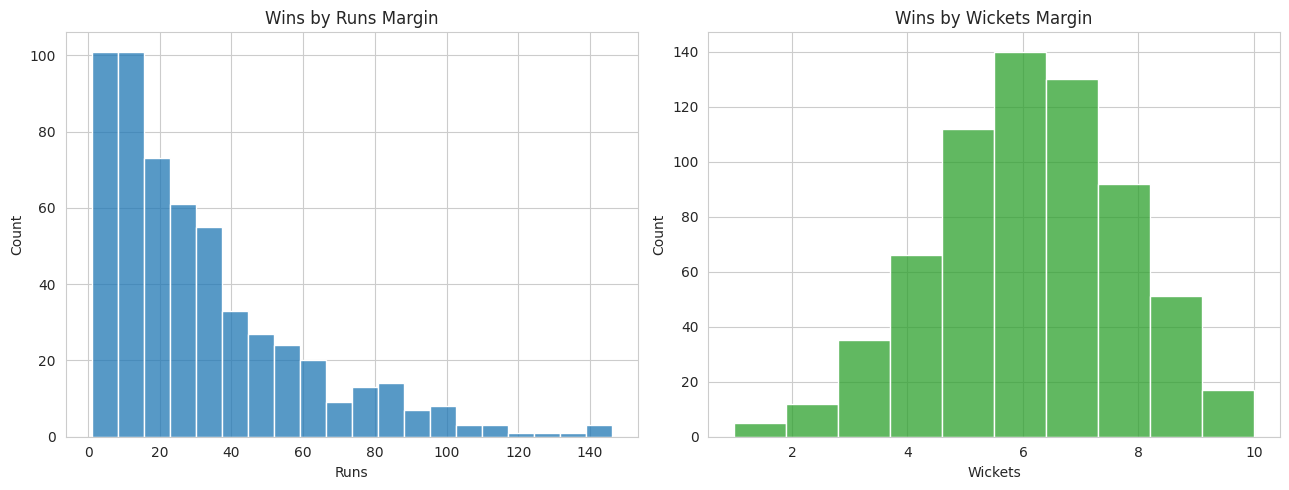

Matches won batting first (by runs): 558
Matches won chasing (by wickets): 660
Median winning margin (runs): 23.0
Median winning margin (wickets): 6.0


In [14]:
win_by_runs_matches = df_complete[df_complete['win_by_runs'] > 0]['win_by_runs']
win_by_wkts_matches = df_complete[df_complete['win_by_wickets'] > 0]['win_by_wickets']

fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.histplot(win_by_runs_matches, bins=20, ax=axes[0], color='#1f77b4')
axes[0].set_title('Wins by Runs Margin')
axes[0].set_xlabel('Runs')

sns.histplot(win_by_wkts_matches, bins=10, ax=axes[1], color='#2ca02c')
axes[1].set_title('Wins by Wickets Margin')
axes[1].set_xlabel('Wickets')
plt.tight_layout()
plt.show()

print(f"Matches won batting first (by runs): {len(win_by_runs_matches)}")
print(f"Matches won chasing (by wickets): {len(win_by_wkts_matches)}")
print(f"Median winning margin (runs): {win_by_runs_matches.median()}")
print(f"Median winning margin (wickets): {win_by_wkts_matches.median()}")


## 11. Key Insights & Conclusion

Based on the analysis above:

- **Mumbai Indians** are the most successful franchise by total wins across IPL history, followed closely by Chennai Super Kings.
- **Gujarat Titans** post the best win percentage among teams with a meaningful sample size (30+ matches), reflecting their strong recent form since debuting in 2022.
- Captains overwhelmingly prefer to **field first** after winning the toss (roughly two-thirds of the time), reflecting the widely-held belief that chasing is easier under IPL conditions (dew, run-chase pressure).
- Teams that chase (field first) win the match slightly more often than teams that bat first when they win the toss, supporting that strategic preference.
- **Eden Gardens** and a handful of other venues have hosted disproportionately more matches, largely because they belong to teams with the longest continuous IPL tenure.
- **AB de Villiers** leads all-time "Player of the Match" awards, reflecting his reputation as one of the most impactful IPL batters.
- Most matches are decided by moderate margins rather than blowouts, indicating a competitive and closely-fought league overall.

This notebook can be extended with player-level ball-by-ball data (if available) for deeper analysis such as strike rates, economy rates, and phase-wise scoring patterns.
